In [ ]:
import os
from scipy.io import loadmat
from utils import save_tensor_as_image

dir = os.path.join(os.path.dirname(os.getcwd()), 'snow_dataset')
masks_dir_path = os.path.join(dir, 'mask_15k_20k')
mask_names = [file_name for file_name in sorted(os.listdir(masks_dir_path)) if
              file_name.endswith('.mat')]

import torch

for mask_name in mask_names:
    x = loadmat(os.path.join(masks_dir_path, mask_name))['inst_map']
    x = (x >= 1).astype(int)
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    save_tensor_as_image(x, os.path.join(dir, 'mask'), mask_name.strip('seed').replace('.mat', ''))



In [1]:
from snow_dataset import SnowDataset
from torchvision.transforms import ToPILImage, Normalize

dataset = SnowDataset()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


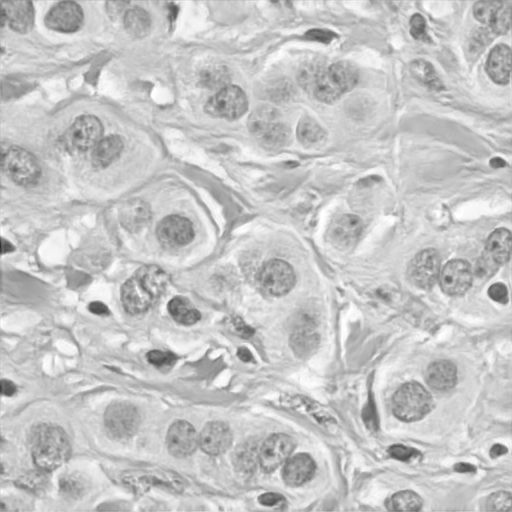

In [3]:
ToPILImage()(dataset[0][0]).convert('L')

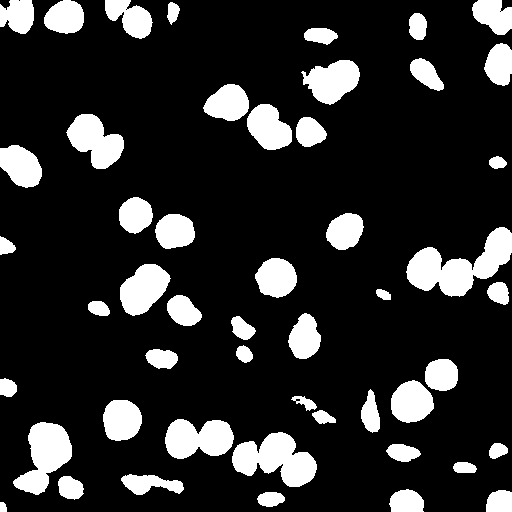

In [6]:
ToPILImage()(dataset[0][1])

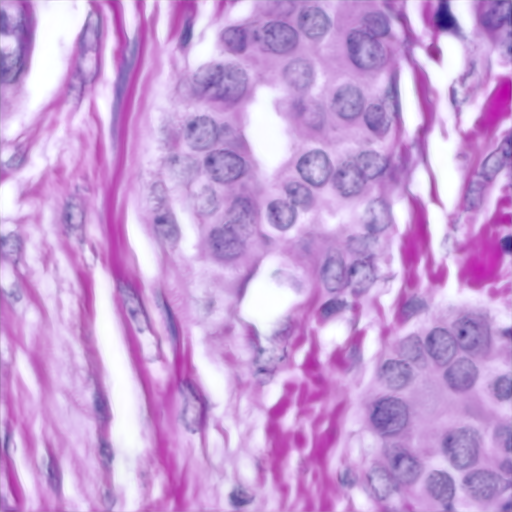

In [11]:
ToPILImage()(dataset[2][0]).greyscale()


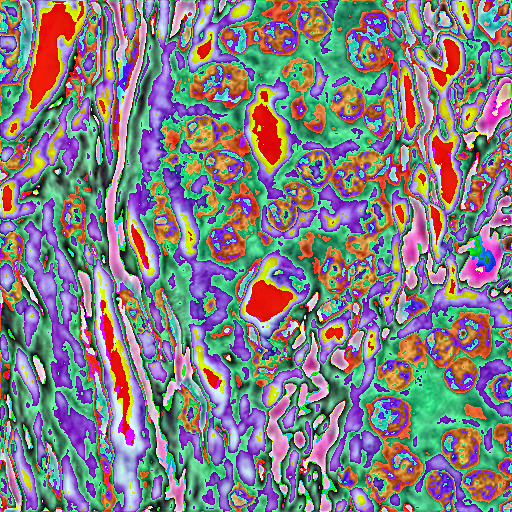

In [18]:
ToPILImage()(Normalize(mean=[0.4808, 0.4178, 0.5046],
                       std=[0.2637, 0.2751, 0.2425])(dataset[2][0]))

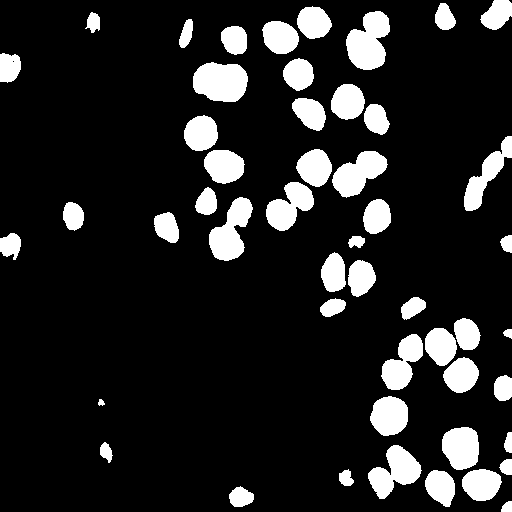

In [23]:
ToPILImage()((dataset[2][1]))

In [ ]:

input_dimensions = (3, 512, 512),
output_dimensions = (1, 512, 512),
num_encoder_stages = 2,
patch_embedding_configs = [
    {
        "patch_embedding_info": {
            'patch_size': 128,
            'in_channels': 1024,
        },
        "encoder_block_configs": [
            {
                'dropout': False,
                'iterations': 3,
                'num_attention_heads': 8,
                'shifted_window': False,
                'window_size': (2, 2)
            },
            {
                'dropout': True,
                'iterations': 3,
                'num_attention_heads': 8,
                'shifted_window': False,
                'window_size': (2, 2)
            },
        ],
        "decoder_block_config": {
            'dropout': True,
            'iterations': 3,
            'num_attention_heads': 8,
            'shifted_window': False,
            'window_size': (2, 2)
        }
    },
],


In [ ]:
"Expected shape (16, 1024), got (64, 768) before `TransformerBlock`."
"Expected shape (16, 1024), got (64, 768) before `TransformerBlock`."